# **Utils module**

The utils module has a variety of utilities mostly focussed on greping on output files of different codes. This tools combined can be usefull for various porpuses.

**<font color='red'>So far the code supports:</font>**
### **Grepping** tools (either by calling the function or using the **file class**):
- Grepping the **number of electrons** of Quantum Espresso and VASP outputs. *(grep_electrons)*
- Grepping the **Fermi level**. *(grep_fermi)*
- Grep the **lattice parameters**. *(grep_lattice)*
- Grep the **path** from a Quantum Espresso bands.pwi or madyn.in input. *(grep_ticks_QE)*
- Grep the **path** from a KPATH in the [TQC website](https://www.topologicalquantumchemistry.fr/#/) format. (Enter in any compound and click in the Download KPATH link). *(grep_ticks_labels_KPATH)*
- Grep the **phonon grid** from a Quantum Espresso ph.x output. *(grep_ph_grid_points)*
- Grep the **total energy** from a Quantum Espresso ph.x output. *(grep_total_energy)*

### **Transforming** tools (mainly usefull changes of coordinates):
- **K_basis**: Obtaining the reciprocal lattice vectors.
- **cartesian2cryst**: From cartesian to crystal coordinates.
- **cryst2cartesian**: From crystal to cartesian coordinates.
- **cartesian2spherical**: From cartesian to spherical coordinates.
- **spherica2cartesian**: From spherical to cartesian coordinates.
- **cryst2spherical**: From crystal to spherical coordinates.
- **spherical2cryst**: From spherical to crystal coordinates.
- **voigt2cartesian**: From voig notation to cartesian notation.
- **cartesian2voigt**: From cartesian notation to voig notation.
---
>*The **documentation** of every function is accesible with the usual **shift + tab** shortcut.*
---

# **I. Grepping tools**

In [2]:
%load_ext autoreload
%autoreload 2
from yaiv import grep

In [1]:
from yaiv import spectrum

## Electrons

In [6]:
nElectrons=grep.electron_num('data/qe/results_scf/Si.scf.pwo')
print('Quantum espreesso used',nElectrons,'electrons.')
nElectrons=grep.electron_num('data/vasp/RESULTS/OUTCAR_BS')
print('VASP used',nElectrons,'electrons.')

Quantum espreesso used 8 electrons.
VASP used 8 electrons.


## Lattice

In [7]:
print('Basis used by Quantum espresso')
print(grep.lattice('data/qe/results_scf/Si.scf.pwo'))
print()
print('Basis used by VASP')
print(grep.lattice('data/vasp/RESULTS/OUTCAR'))

Basis used by Quantum espresso
[[0.0 2.7343648234158016 2.7343648234158016] [2.7343648234158016 0.0 2.7343648234158016] [2.7343648234158016 2.7343648234158016 0.0]] angstrom

Basis used by VASP
[[0.0 2.734363998 2.734363998] [2.734363998 0.0 2.734363998] [2.734363998 2.734363998 0.0]] angstrom


## Fermi level

In [8]:
#Fermi level
fermi=grep.fermi('data/qe/results_scf/Si.scf.pwo')
print('Quantum espreesso\'s fermi level is',fermi)
fermi=grep.fermi('data/vasp/RESULTS/OUTCAR_SCC')
print('VASP\'s fermi level is',fermi)

Quantum espreesso's fermi level is 6.3627 electron_volt
VASP's fermi level is 6.1723 electron_volt


## Total energy (and energy decomposition)

In [9]:
energy=grep.total_energy('data/qe/results_scf/Si.scf.pwo')
print('Total energy in QE:',energy)
energy=grep.total_energy('data/vasp/RESULTS/OUTCAR')
print('Total energy in VASP:',energy)

Total energy in QE: -93.77214097 rydberg
Total energy in VASP: -0.5820532903697593 rydberg


In [10]:
energy=grep.total_energy('data/qe/results_scf/Si.scf.pwo',decomposition=True)
print('Free energy=',energy.F)
print('Internal energy=',energy.U)
print('Entropy contribution=',energy.TS)
print('Single electron energy=',energy.U_one_electron)
print('Hartree energy=',energy.U_hartree)
print('Exchange-correlation energy=',energy.U_xc)
print('Ewald energy=',energy.U_ewald)

Free energy= -93.77214097 rydberg
Internal energy= -93.76999657 rydberg
Entropy contribution= -0.0021444 rydberg
Single electron energy= 5.73621994 rydberg
Hartree energy= 1.13562264 rydberg
Exchange-correlation energy= -12.81773185 rydberg
Ewald energy= -16.67997833 rydberg


## Stress tensor

In [1]:
print('Stress tensor in QE')
print(grep.stress_tensor('data/qe/results_scf/Si.scf.pwo'))
print()
print('Stress tensor in VASP')
print(grep.stress_tensor('data/vasp/RESULTS/OUTCAR'))

Stress tensor in QE
[[376.7405191442384 0.0 0.0] [0.0 376.7405191442384 0.0] [0.0 0.0 376.7405191442384]] kilobar

Stress tensor in VASP
[[34.82684 -0.0 0.0] [-0.0 34.82684 -0.0] [0.0 -0.0 34.82684]] kilobar


/u/51/gutierm2/unix/Software/YAIV/build/__editable__.yaiv-1.0.0-py3-none-any/yaiv/grep.py:393: UserWarning: According to VASP this is kB units, but when comparing to QE it appears to be GPa.
  warnings.warn(


## K-paths

In [6]:
False is False

True

In [1]:
kpath=grep.kpath('data/qe/results_bands/Si.bands.pwi')
print('QE path:', kpath.labels)
print(kpath.path)
print()
kpath=grep.kpath('data/vasp/RESULTS/KPATH')
print('VASP:', kpath.labels)
print(kpath.path)
print()

QE path: ['X', 'W', 'L', 'Gamma', 'X', 'X_1', 'K', 'U', 'Gamma']
[[0.5 0.0 0.5 20.0] [0.5 0.25 0.75 20.0] [0.5 0.5 0.5 20.0] [0.0 0.0 0.0 20.0] [0.5 0.0 0.5 1.0] [0.5 0.5 1.0 20.0] [0.375 0.375 0.75 20.0] [0.125 0.125 0.25 20.0] [0.0 0.0 0.0 1.0]] _2pi / crystal

VASP: ['X', 'W', 'L', 'Gamma', 'X', 'X_1', 'K', 'U', 'Gamma']
[[0.5 0.0 0.5 20.0] [0.5 0.25 0.75 20.0] [0.5 0.5 0.5 20.0] [0.0 0.0 0.0 20.0] [0.5 0.0 0.5 1.0] [0.5 0.5 1.0 20.0] [0.375 0.375 0.75 20.0] [0.125 0.125 0.25 20.0] [0.0 0.0 0.0 1.0]] _2pi / crystal



## Kpoints and energies

In [15]:
print('Quantum Espresso example:')
E=grep.kpointsEnergies('data/qe/results_bands/Si.bands.pwo')
print(f"Energies, ({E.eigenvalues.units}):")
print(E.eigenvalues[:3,:4],)
print(f"Kpoints, ({E.kpoints.units}):")
print(E.kpoints[:5])
print('Weights:')
print(E.weights[:5])

Quantum Espresso example:
Energies, (electron_volt):
[[-1.5082 -1.5082 -1.5082 -1.5082] [-1.5071 -1.5071 -1.5071 -1.5071] [-1.5038 -1.5038 -1.5038 -1.5038]] electron_volt
Kpoints, (_2pi / crystal):
[[0.5 0.0 0.5] [0.5 0.0125 0.5125] [0.5 0.025 0.525] [0.5 0.0375 0.5375] [0.5 0.05 0.55]] _2pi / crystal
Weights:
[0.0070423 0.0070423 0.0070423 0.0070423 0.0070423]


In [2]:
print('VASP EIGENVAL example:')
E=grep.kpointsEnergies('data/vasp/RESULTS/EIGENVAL')
print(f"Energies, ({E.eigenvalues.units}):")
print(E.eigenvalues[:3,:4],)
print(f"Kpoints, ({E.kpoints.units}):")
print(E.kpoints[:5])
print('Weights:')
print(E.weights[:5])

VASP EIGENVAL example:
Energies, (electron_volt):
[[-1.86626 -1.866259 3.089611 3.089627] [-1.865252 -1.865251 3.08052 3.080536] [-1.862249 -1.862248 3.053846 3.053862]] electron_volt
Kpoints, (_2pi / crystal):
[[0.5 0.0 0.5] [0.5 0.01315789 0.5131579] [0.5 0.02631579 0.5263158] [0.5 0.03947368 0.5394737] [0.5 0.05263158 0.5526316]] _2pi / crystal
Weights:
[0.00714286 0.00714286 0.00714286 0.00714286 0.00714286]


In [3]:
print('VASP OUTCAR example:')
E=grep.kpointsEnergies('data/vasp/RESULTS/OUTCAR')
print(f"Energies, ({E.eigenvalues.units}):")
print(E.eigenvalues[:3,:4],)
print(f"Kpoints, ({E.kpoints.units}):")
print(E.kpoints[:5])
print('Weights:')
print(E.weights[:5])

VASP OUTCAR example:
Energies, (electron_volt):
[[-1.8663 -1.8663 3.0896 3.0896] [-1.8653 -1.8653 3.0805 3.0805] [-1.8622 -1.8622 3.0538 3.0539]] electron_volt
Kpoints, (_2pi / crystal):
[[0.5 0.0 0.5] [0.5 0.013158 0.513158] [0.5 0.026316 0.526316] [0.5 0.039474 0.539474] [0.5 0.052632 0.552632]] _2pi / crystal
Weights:
[0.007143 0.007143 0.007143 0.007143 0.007143]


## Kpoints and frequencies

In [1]:
print('Quantum Espresso example:')
F=grep.kpointsFrequencies('data/qe/results_matdyn/Si.freq')
print(f"Frequencies ({F.eigenvalues.units}):")
print(F.eigenvalues[:2])
print(f"Kpoints ({F.kpoints.units}):")
print(F.kpoints[:5])

Quantum Espresso example:
Frequencies (speed_of_light / centimeter):
[[689.1662 689.1662 897.3373 897.3373 946.9531 946.9531] [689.4236 689.4236 897.1973 897.1973 947.1141 947.1141]] speed_of_light / centimeter
Kpoints (_2pi / alat):
[[0.0 0.707107 0.0] [0.017678 0.707107 0.0] [0.035355 0.707107 0.0] [0.053033 0.707107 0.0] [0.070711 0.707107 0.0]] _2pi / alat


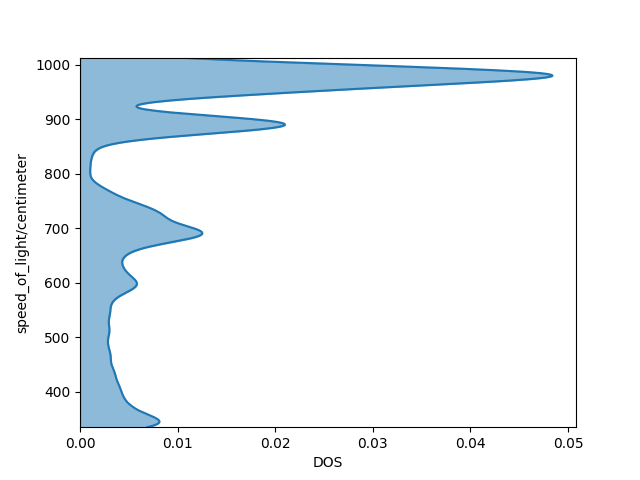

In [4]:
#shift=5*ureg('eV')
window=[600,900]*ureg('c/cm')
fermi=4*ureg('eV')
x=F.plot_DOS(switchXY=True)
plt.show()

<Axes: xlabel='_2pi/crystal', ylabel='electron_volt'>

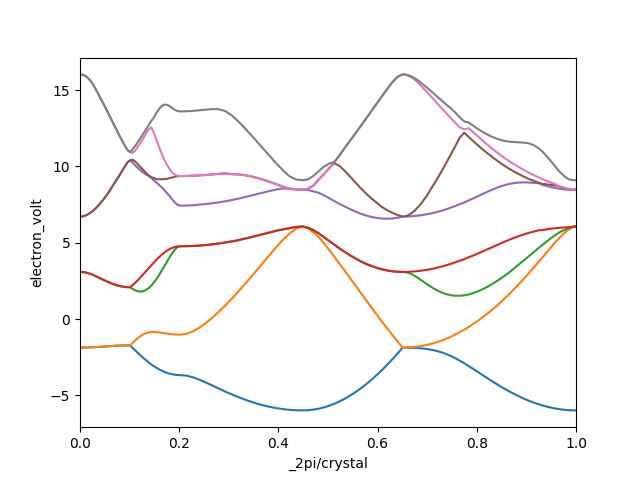

In [19]:
E.plot()

In [2]:
F.get_DOS()

In [7]:
F.DOS.vgrid

<Quantity([ 334.5404      335.900698    337.26099599  338.62129399  339.98159198
  341.34188998  342.70218798  344.06248597  345.42278397  346.78308196
  348.14337996  349.50367796  350.86397595  352.22427395  353.58457194
  354.94486994  356.30516794  357.66546593  359.02576393  360.38606192
  361.74635992  363.10665792  364.46695591  365.82725391  367.1875519
  368.5478499   369.9081479   371.26844589  372.62874389  373.98904188
  375.34933988  376.70963788  378.06993587  379.43023387  380.79053186
  382.15082986  383.51112786  384.87142585  386.23172385  387.59202184
  388.95231984  390.31261784  391.67291583  393.03321383  394.39351182
  395.75380982  397.11410782  398.47440581  399.83470381  401.1950018
  402.5552998   403.9155978   405.27589579  406.63619379  407.99649178
  409.35678978  410.71708778  412.07738577  413.43768377  414.79798176
  416.15827976  417.51857776  418.87887575  420.23917375  421.59947174
  422.95976974  424.32006774  425.68036573  427.04066373  428.40096172
  429.76125972  431.12155772  432.48185571  433.84215371  435.2024517
  436.5627497   437.9230477   439.28334569  440.64364369  442.00394168
  443.36423968  444.72453768  446.08483567  447.44513367  448.80543166
  450.16572966  451.52602766  452.88632565  454.24662365  455.60692164
  456.96721964  458.32751764  459.68781563  461.04811363  462.40841162
  463.76870962  465.12900762  466.48930561  467.84960361  469.2099016
  470.5701996   471.9304976   473.29079559  474.65109359  476.01139158
  477.37168958  478.73198758  480.09228557  481.45258357  482.81288156
  484.17317956  485.53347756  486.89377555  488.25407355  489.61437154
  490.97466954  492.33496754  493.69526553  495.05556353  496.41586152
  497.77615952  499.13645752  500.49675551  501.85705351  503.2173515
  504.5776495   505.93794749  507.29824549  508.65854349  510.01884148
  511.37913948  512.73943747  514.09973547  515.46003347  516.82033146
  518.18062946  519.54092745  520.90122545  522.26152345  523.62182144
  524.98211944  526.34241743  527.70271543  529.06301343  530.42331142
  531.78360942  533.14390741  534.50420541  535.86450341  537.2248014
  538.5850994   539.94539739  541.30569539  542.66599339  544.02629138
  545.38658938  546.74688737  548.10718537  549.46748337  550.82778136
  552.18807936  553.54837735  554.90867535  556.26897335  557.62927134
  558.98956934  560.34986733  561.71016533  563.07046333  564.43076132
  565.79105932  567.15135731  568.51165531  569.87195331  571.2322513
  572.5925493   573.95284729  575.31314529  576.67344329  578.03374128
  579.39403928  580.75433727  582.11463527  583.47493327  584.83523126
  586.19552926  587.55582725  588.91612525  590.27642325  591.63672124
  592.99701924  594.35731723  595.71761523  597.07791323  598.43821122
  599.79850922  601.15880721  602.51910521  603.87940321  605.2397012
  606.5999992   607.96029719  609.32059519  610.68089319  612.04119118
  613.40148918  614.76178717  616.12208517  617.48238317  618.84268116
  620.20297916  621.56327715  622.92357515  624.28387315  625.64417114
  627.00446914  628.36476713  629.72506513  631.08536313  632.44566112
  633.80595912  635.16625711  636.52655511  637.88685311  639.2471511
  640.6074491   641.96774709  643.32804509  644.68834309  646.04864108
  647.40893908  648.76923707  650.12953507  651.48983307  652.85013106
  654.21042906  655.57072705  656.93102505  658.29132305  659.65162104
  661.01191904  662.37221703  663.73251503  665.09281303  666.45311102
  667.81340902  669.17370701  670.53400501  671.89430301  673.254601
  674.614899    675.97519699  677.33549499  678.69579299  680.05609098
  681.41638898  682.77668697  684.13698497  685.49728297  686.85758096
  688.21787896  689.57817695  690.93847495  692.29877295  693.65907094
  695.01936894  696.37966693  697.73996493  699.10026293  700.46056092
  701.82085892  703.18115691  704.54145491  705.90175291  707.2620509
  708.6223489   709.98264689  711.34294489  712.70324289  714.06354088
  715.42383888  716.784136

In [5]:
states=simpson(F.DOS.DOS,F.DOS.vgrid)
print(states)

5.817383521693241


In [6]:

states=np.trapezoid(F.DOS.DOS,F.DOS.vgrid.magnitude)
print(states)

5.817170123253165


In [3]:

from scipy.integrate import simpson
from numpy import trapz

In [ ]:
simpson()

In [ ]:
from scipy.integrate import simpson
from numpy import trapz


# The y values.  A numpy array is used here,
# but a python list could also be used.
y = np.array([5, 20, 4, 18, 19, 18, 7, 4])

# Compute the area using the composite trapezoidal rule.
area = trapz(y, dx=5)
print("area =", area)

# Compute the area using the composite Simpson's rule.
area = simpson(y, dx=5)
print("area =", area)


In [15]:
np.sum(F.DOS.DOS)

np.float64(4.1983867746125405)

In [13]:
F.weights

In [24]:
X,DOS=ut.density_of_states(F.eigenvalues)

In [27]:
type(X)

pint.Quantity

In [26]:

np.sum(DOS)

np.float64(6.7319919170527855)

/u/51/gutierm2/unix/Software/enviroments/yaiv-dev/lib/python3.10/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


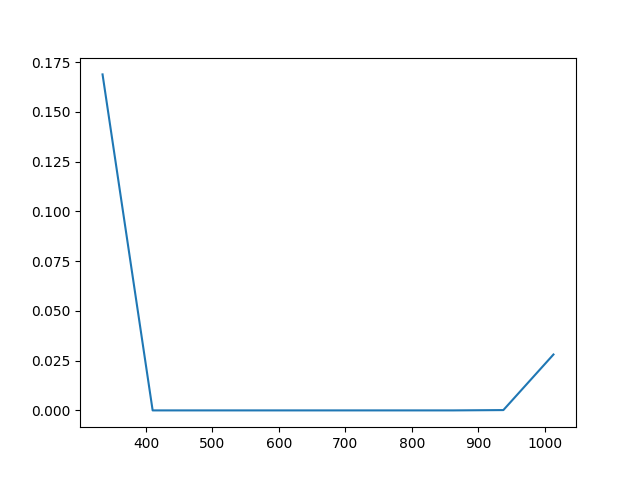

In [23]:
plt.figure()
plt.plot(X,DOS)
plt.show()

--- 
Edited until here more or less...

## BandGAP

In [5]:
direct,indirect=qe_out.grep_gap()
print('For QE:')
print('Direct gap= ',direct,'eV , Indirect gap=', indirect, ' meV')

NameError: name 'qe_out' is not defined

## Kpoints, energies and projections

Scrapping of either:
- Quantum Espresso **proj.pwo** output 
- VASP PROCAR file

for further postprocessing.

In [ ]:
returns STATES, KPOINTS, ENERGIES, PROJECTIONS=qe_out.grep_kpoints_energies_projections()

## Phonon grid

In [9]:
#Read the phonon grid and structure from a ph.x output
ph_out=utils.file('DATA/phonons/3x3x2/results_ph/CsV3Sb5.ph.pwo')
ph_out.grep_ph_grid_points()
print('The phonon grid used in the calculation is:')
print(ph_out.ph_grid_points)

The phonon grid used in the calculation is:
[[ 0.     0.     0.   ]
 [ 0.     0.    -0.5  ]
 [ 0.     0.333  0.   ]
 [-0.333  0.333  0.   ]
 [ 0.333 -0.     0.   ]
 [-0.333  0.     0.   ]
 [ 0.333 -0.333  0.   ]
 [ 0.    -0.333  0.   ]
 [ 0.     0.333 -0.5  ]
 [-0.333  0.333 -0.5  ]
 [ 0.333 -0.    -0.5  ]
 [-0.333  0.    -0.5  ]
 [ 0.333 -0.333 -0.5  ]
 [ 0.    -0.333  0.5  ]
 [ 0.333  0.333  0.   ]
 [-0.333 -0.333  0.   ]
 [ 0.333  0.333 -0.5  ]
 [-0.333 -0.333  0.5  ]]


# II. Transforming tools

In [30]:
qe_out=utils.file('DATA/bands/QE/results_scf/CsV3Sb5.scf.pwo')
rec_basis=qe_out.reciprocal_lattice()
print('Reciprocal basis:')
print(rec_basis)
print()
M_cryst=[1/2,0,0]
M_cart=utils.cryst2cartesian(M_cryst,rec_basis)
print('The M point in crystal units is:', M_cryst)
print('The M point in cartesian units is:', M_cart)

Reciprocal basis:
[[0.18169622 0.10490241 0.        ]
 [0.         0.20980483 0.        ]
 [0.         0.         0.10123757]]

The M point in crystal units is: [0.5, 0, 0]
The M point in cartesian units is: [0.09084811 0.05245121 0.        ]
